<a href="https://colab.research.google.com/github/Ayush-Gole8/DeepLearning/blob/main/23102A0005_3_skin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Disease Detection using CNN
This notebook demonstrates how to download a dataset from Kaggle, preprocess image data, and implement/compare CNN models for skin disease classification.

### 1. Setup Kaggle API
To download the dataset, you need a `kaggle.json` file from your Kaggle account settings. Upload it to the runtime or use the secrets manager.

In [ ]:
import os
import kagglehub

# Download dataset
path = kagglehub.dataset_download("subirbiswas19/skin-disease-dataset")
print(f"Dataset downloaded to: {path}")

# Point data_dir to the downloaded path
data_dir = path
!ls "{data_dir}"

100%|██████████| 17.3M/17.3M [00:00<00:00, 75.0MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/subirbiswas19/skin-disease-dataset/versions/1
skin-disease-datasaet


### 2. Data Preparation
We will use `ImageDataGenerator` or `image_dataset_from_directory` to load and augment the images.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load datasets from the kagglehub path
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found: {class_names}")

Found 1157 files belonging to 1 classes.
Using 926 files for training.
Found 1157 files belonging to 1 classes.
Using 231 files for validation.
Classes found: ['skin-disease-datasaet']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

AUTOTUNE = tf.data.AUTOTUNE

# Data augmentation layer (active only during training)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# Optimized training and validation streams
train_ds_proc = (
    train_ds
    .cache()
    .shuffle(buffer_size=1000)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds_proc = (
    val_ds
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

### 3. Build a Simple CNN Model
We'll start with a baseline convolutional neural network.

In [ ]:
def build_simple_cnn(num_classes):
    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_simple_cnn(len(class_names))
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 346112)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    44,302,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,395,841 (169.36 MB)

 Trainable params: 44,395,841 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Comparison: Transfer Learning with MobileNetV2
To compare performance, we'll implement a pre-trained model.

In [ ]:
def build_transfer_model(num_classes):
    base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(num_classes, activation='softmax' if num_classes > 1 else 'sigmoid')
    ])

    loss_fn = 'sparse_categorical_crossentropy' if num_classes > 1 else 'binary_crossentropy'
    model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
    return model

# Re-initialize models with correct class count
cnn_model = build_simple_cnn(num_classes)
transfer_model = build_transfer_model(num_classes)

print("Training Simple CNN...")
history_simple = cnn_model.fit(train_ds_proc, validation_data=val_ds_proc, epochs=5)

print("\nTraining MobileNetV2 Transfer Model...")
history_transfer = transfer_model.fit(train_ds_proc, validation_data=val_ds_proc, epochs=5)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Simple CNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 313ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00

Training MobileNetV2 Transfer Model...
Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9287 - loss: 0.1474 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 3

In [ ]:
# ----------------------------------------------------
# 1. EfficientNetB0
# ----------------------------------------------------
def build_efficientnet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)

    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=x
    )
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="EfficientNetB0")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ----------------------------------------------------
# 2. DenseNet121 (Standard for Dermatology / Medical AI)
# ----------------------------------------------------
def build_densenet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.densenet.preprocess_input(x)

    base_model = tf.keras.applications.DenseNet121(
        include_top=False,
        weights='imagenet',
        input_tensor=x
    )
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="DenseNet121")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Instantiate models
num_classes = len(class_names)
efficientnet_model = build_efficientnet_model(num_classes)
densenet_model = build_densenet_model(num_classes)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
EPOCHS = 8

print("\n--- Training EfficientNetB0 ---")
history_effnet = efficientnet_model.fit(
    train_ds_proc,
    validation_data=val_ds_proc,
    epochs=EPOCHS
)

print("\n--- Training DenseNet121 ---")
history_densenet = densenet_model.fit(
    train_ds_proc,
    validation_data=val_ds_proc,
    epochs=EPOCHS
)


--- Training EfficientNetB0 ---
Epoch 1/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.000

ValueError: x and y must have same first dimension, but have shapes (5,) and (8,)

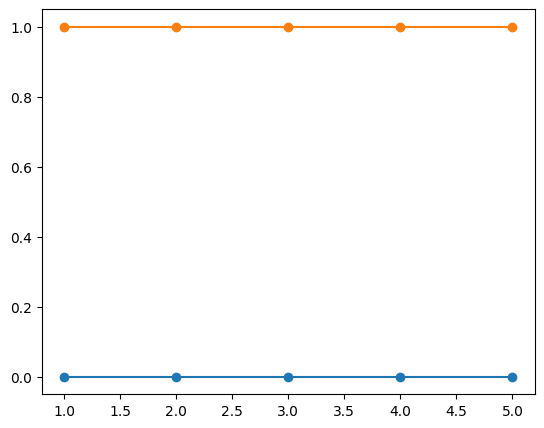

In [ ]:
import matplotlib.pyplot as plt

def plot_all_models(history_dict):
    """
    history_dict: dict of { 'Model Name': history_object }
    """
    epochs_range = range(1, len(next(iter(history_dict.values())).history['accuracy']) + 1)

    plt.figure(figsize=(14, 5))

    # 1. Validation Accuracy Plot
    plt.subplot(1, 2, 1)
    for name, hist in history_dict.items():
        plt.plot(epochs_range, hist.history['val_accuracy'], marker='o', label=f'{name} (Val Acc)')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # 2. Validation Loss Plot
    plt.subplot(1, 2, 2)
    for name, hist in history_dict.items():
        plt.plot(epochs_range, hist.history['val_loss'], marker='o', label=f'{name} (Val Loss)')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Compare all models side-by-side
plot_all_models({
    "Simple CNN": history_simple,
    "MobileNetV2": history_transfer,
    "EfficientNetB0": history_effnet,
    "DenseNet121": history_densenet
})

### 5. Performance Comparison
We will now plot the accuracy and loss for both models to compare their performance.

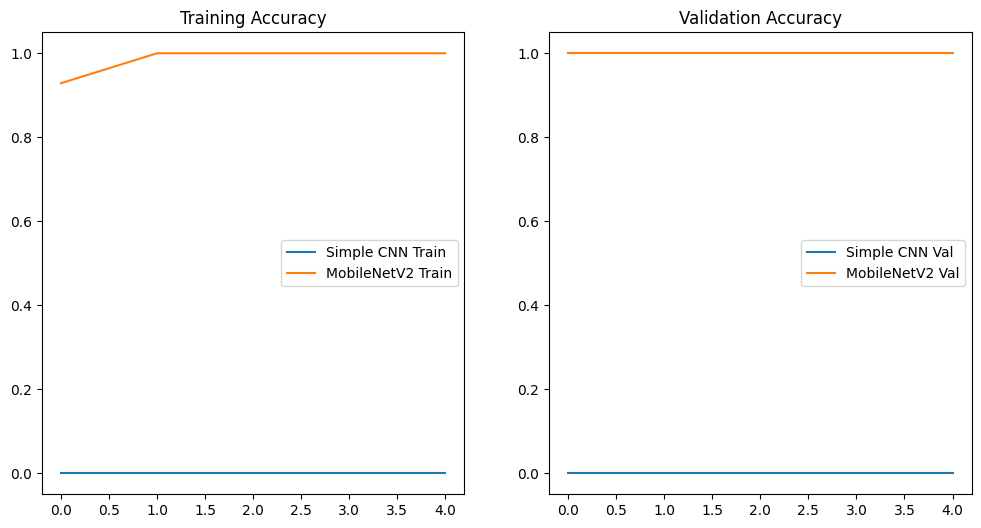

In [ ]:
import matplotlib.pyplot as plt

def plot_comparison(h1, h2, name1="Simple CNN", name2="MobileNetV2"):
    acc1 = h1.history['accuracy']
    val_acc1 = h1.history['val_accuracy']
    acc2 = h2.history['accuracy']
    val_acc2 = h2.history['val_accuracy']

    epochs_range = range(len(acc1))

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc1, label=f'{name1} Train')
    plt.plot(epochs_range, acc2, label=f'{name2} Train')
    plt.title('Training Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, val_acc1, label=f'{name1} Val')
    plt.plot(epochs_range, val_acc2, label=f'{name2} Val')
    plt.title('Validation Accuracy')
    plt.legend()
    plt.show()

plot_comparison(history_simple, history_transfer)

Train directory: /kaggle/input/skin-disease-dataset/skin-disease-datasaet/train_set
Test directory:  /kaggle/input/skin-disease-dataset/skin-disease-datasaet/test_set
Found 924 files belonging to 8 classes.
Found 233 files belonging to 8 classes.

Successfully loaded 8 classes:
  [0] BA- cellulitis
  [1] BA-impetigo
  [2] FU-athlete-foot
  [3] FU-nail-fungus
  [4] FU-ringworm
  [5] PA-cutaneous-larva-migrans
  [6] VI-chickenpox
  [7] VI-shingles


/tmp/ipykernel_3296/4011588355.py:80: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=x)



--- Training Simple CNN ---
Epoch 1/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.1537 - loss: 4.1564 - val_accuracy: 0.2017 - val_loss: 1.9767
Epoch 2/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.2002 - loss: 1.9866 - val_accuracy: 0.2232 - val_loss: 1.9175
Epoch 3/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.2543 - loss: 1.8778 - val_accuracy: 0.2532 - val_loss: 1.8466
Epoch 4/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.2684 - loss: 1.8391 - val_accuracy: 0.2876 - val_loss: 1.8314
Epoch 5/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.2792 - loss: 1.8189 - val_accuracy: 0.3519 - val_loss: 1.7704
Epoch 6/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.3496 - loss: 1.7341 - val_accuracy: 0.3433 - val_loss: 1.7911
Epoch 7/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.3745 - loss: 1.6614 - val_accuracy: 0.4120 - val_loss: 1.7636
Epoch 8/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.4253 - loss: 1.5385 - va

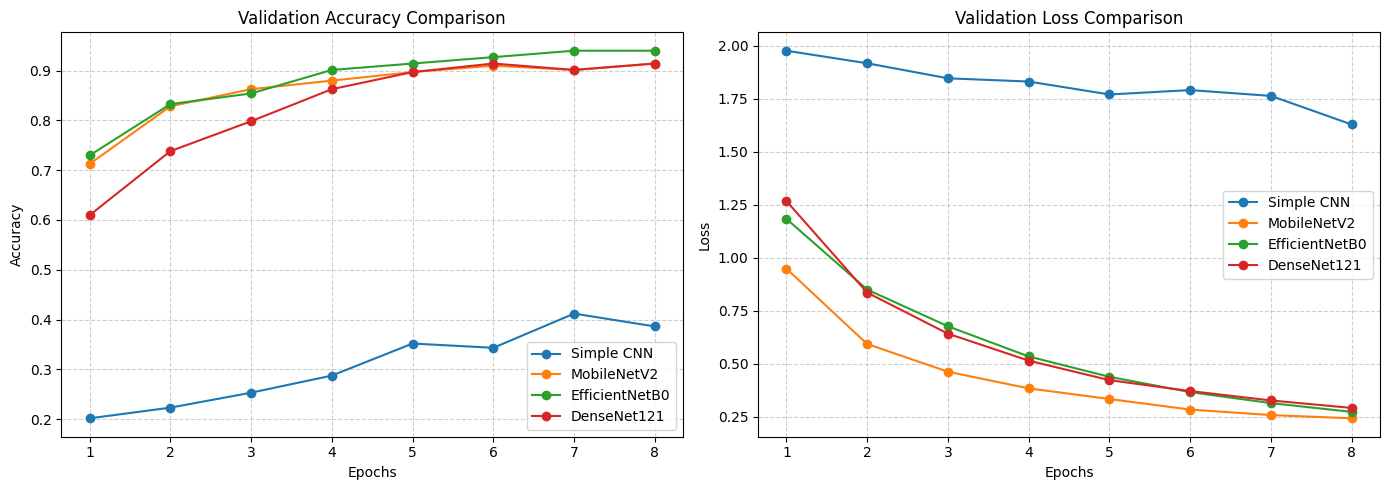

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers

# Construct paths to train and test sets
train_dir = os.path.join(path, "skin-disease-datasaet", "train_set")
test_dir = os.path.join(path, "skin-disease-datasaet", "test_set")

# Fallback in case kagglehub extracted directly into path
if not os.path.exists(train_dir):
    train_dir = os.path.join(path, "train_set")
    test_dir = os.path.join(path, "test_set")

print(f"Train directory: {train_dir}")
print(f"Test directory:  {test_dir}")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 1. Load Training Set
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

# 2. Load Validation/Test Set
val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nSuccessfully loaded {num_classes} classes:")
for i, name in enumerate(class_names):
    print(f"  [{i}] {name}")

# 3. Optimized Data Pipeline & Augmentation
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

train_ds_proc = train_ds.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
val_ds_proc = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ----------------------------------------------------
# 3. Model Builders
# ----------------------------------------------------
def build_simple_cnn(num_classes):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="Simple_CNN")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_mobilenet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="MobileNetV2")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_efficientnet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="EfficientNetB0")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_densenet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.densenet.preprocess_input(x)
    base_model = tf.keras.applications.DenseNet121(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="DenseNet121")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ----------------------------------------------------
# 4. Training (Standardized Epochs)
# ----------------------------------------------------
EPOCHS = 8

models_to_train = {
    "Simple CNN": build_simple_cnn(num_classes),
    "MobileNetV2": build_mobilenet_model(num_classes),
    "EfficientNetB0": build_efficientnet_model(num_classes),
    "DenseNet121": build_densenet_model(num_classes)
}

histories = {}
for name, model in models_to_train.items():
    print(f"\n--- Training {name} ---")
    histories[name] = model.fit(
        train_ds_proc,
        validation_data=val_ds_proc,
        epochs=EPOCHS
    )

# ----------------------------------------------------
# 5. Robust Multi-Model Evaluation Plot
# ----------------------------------------------------
def plot_all_models(history_dict):
    plt.figure(figsize=(14, 5))

    # 1. Validation Accuracy Plot
    plt.subplot(1, 2, 1)
    for name, hist in history_dict.items():
        epochs_range = range(1, len(hist.history['val_accuracy']) + 1)
        plt.plot(epochs_range, hist.history['val_accuracy'], marker='o', label=f'{name}')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # 2. Validation Loss Plot
    plt.subplot(1, 2, 2)
    for name, hist in history_dict.items():
        epochs_range = range(1, len(hist.history['val_loss']) + 1)
        plt.plot(epochs_range, hist.history['val_loss'], marker='o', label=f'{name}')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_all_models(histories)

Train directory: /kaggle/input/skin-disease-dataset/skin-disease-datasaet/train_set
Test directory:  /kaggle/input/skin-disease-dataset/skin-disease-datasaet/test_set
Found 924 files belonging to 8 classes.
Found 233 files belonging to 8 classes.

Successfully loaded 8 classes:
  [0] BA- cellulitis
  [1] BA-impetigo
  [2] FU-athlete-foot
  [3] FU-nail-fungus
  [4] FU-ringworm
  [5] PA-cutaneous-larva-migrans
  [6] VI-chickenpox
  [7] VI-shingles


/tmp/ipykernel_3296/3309869840.py:96: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=x)



 TRAINING: Simple CNN
Epoch 1/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.1526 - loss: 3.2026 - val_accuracy: 0.2489 - val_loss: 1.9560
Epoch 2/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.2630 - loss: 1.9188 - val_accuracy: 0.3562 - val_loss: 1.7840
Epoch 3/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.3106 - loss: 1.8091 - val_accuracy: 0.3133 - val_loss: 1.8211
Epoch 4/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.3236 - loss: 1.7613 - val_accuracy: 0.3133 - val_loss: 1.7463
Epoch 5/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.3853 - loss: 1.6853 - val_accuracy: 0.3863 - val_loss: 1.6933
Epoch 6/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.4048 - loss: 1.6114 - val_accuracy: 0.3820 - val_loss: 1.6484
Epoch 7/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.4210 - loss: 1.5494 - val_accuracy: 0.3734 - val_loss: 1.6686
Epoch 8/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.4253 - loss: 1.5011 - val_accu

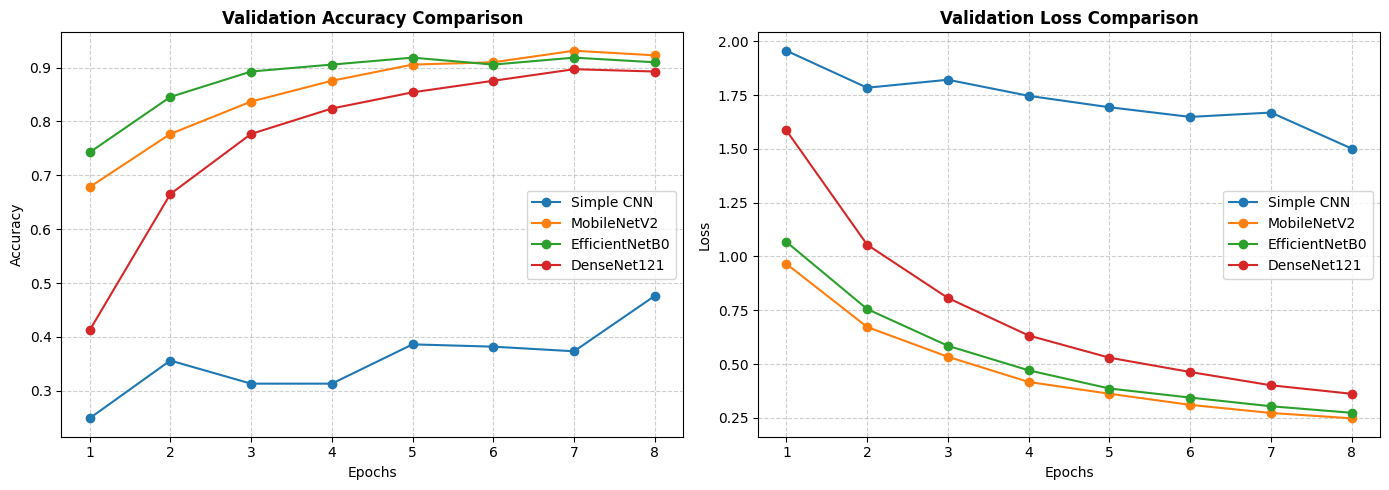

Generating predictions for Simple CNN...
Generating predictions for MobileNetV2...
Generating predictions for EfficientNetB0...


Generating predictions for DenseNet121...



             OVERALL MODEL PERFORMANCE SUMMARY
         Model  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)
   MobileNetV2  0.922747              0.925794           0.922747             0.922832
EfficientNetB0  0.909871              0.914804           0.909871             0.910110
   DenseNet121  0.892704              0.896462           0.892704             0.892768
    Simple CNN  0.476395              0.466844           0.476395             0.447259

 CLASSIFICATION REPORT: MOBILENETV2 (TOP PERFORMER)
                            precision    recall  f1-score   support

            BA- cellulitis       0.89      1.00      0.94        33
               BA-impetigo       0.89      0.85      0.87        20
           FU-athlete-foot       0.91      0.94      0.92        32
            FU-nail-fungus       1.00      0.94      0.97        33
               FU-ringworm       0.95      0.83      0.88        23
PA-cutaneous-larva-migrans       0.82      0.92      0.

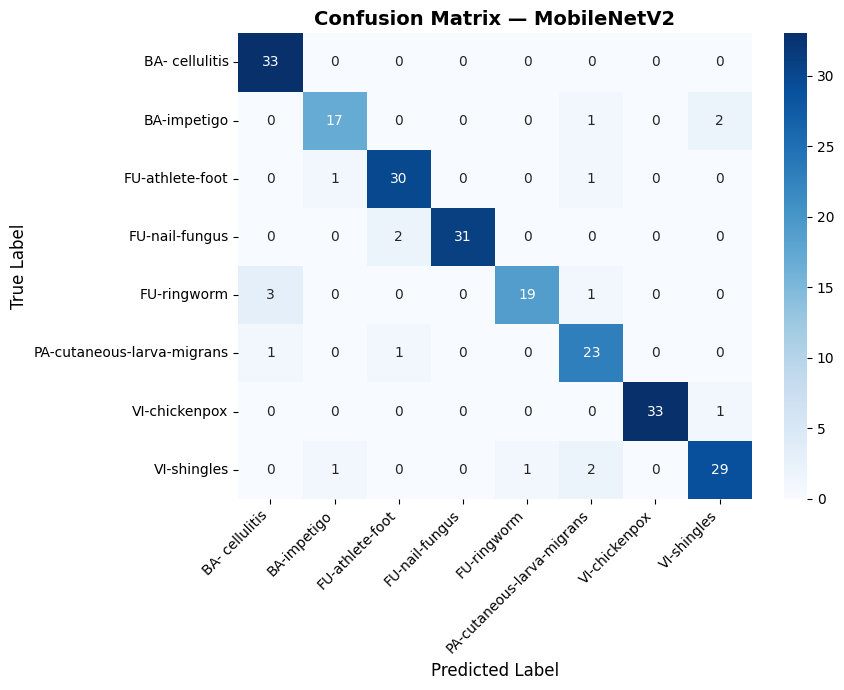

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ----------------------------------------------------
# 1. Path Resolution & Dataset Loading
# ----------------------------------------------------
train_dir = os.path.join(path, "skin-disease-datasaet", "train_set")
test_dir = os.path.join(path, "skin-disease-datasaet", "test_set")

# Fallback in case kagglehub extracted without the parent folder
if not os.path.exists(train_dir):
    train_dir = os.path.join(path, "train_set")
    test_dir = os.path.join(path, "test_set")

print(f"Train directory: {train_dir}")
print(f"Test directory:  {test_dir}")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load Training Set
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

# Load Validation/Test Set
val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nSuccessfully loaded {num_classes} classes:")
for i, name in enumerate(class_names):
    print(f"  [{i}] {name}")

# ----------------------------------------------------
# 2. Optimized Pipeline & Data Augmentation
# ----------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

train_ds_proc = train_ds.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
val_ds_proc = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ----------------------------------------------------
# 3. Model Architectures
# ----------------------------------------------------
def build_simple_cnn(num_classes):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="Simple_CNN")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_mobilenet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="MobileNetV2")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_efficientnet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="EfficientNetB0")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_densenet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.densenet.preprocess_input(x)
    base_model = tf.keras.applications.DenseNet121(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="DenseNet121")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ----------------------------------------------------
# 4. Multi-Model Training
# ----------------------------------------------------
EPOCHS = 8

models_to_train = {
    "Simple CNN": build_simple_cnn(num_classes),
    "MobileNetV2": build_mobilenet_model(num_classes),
    "EfficientNetB0": build_efficientnet_model(num_classes),
    "DenseNet121": build_densenet_model(num_classes)
}

histories = {}
for name, model in models_to_train.items():
    print(f"\n" + "="*50)
    print(f" TRAINING: {name}")
    print("="*50)
    histories[name] = model.fit(
        train_ds_proc,
        validation_data=val_ds_proc,
        epochs=EPOCHS
    )

# ----------------------------------------------------
# 5. Training History Visualizations
# ----------------------------------------------------
def plot_all_models(history_dict):
    plt.figure(figsize=(14, 5))

    # Validation Accuracy Plot
    plt.subplot(1, 2, 1)
    for name, hist in history_dict.items():
        epochs_range = range(1, len(hist.history['val_accuracy']) + 1)
        plt.plot(epochs_range, hist.history['val_accuracy'], marker='o', label=f'{name}')
    plt.title('Validation Accuracy Comparison', fontsize=12, weight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Validation Loss Plot
    plt.subplot(1, 2, 2)
    for name, hist in history_dict.items():
        epochs_range = range(1, len(hist.history['val_loss']) + 1)
        plt.plot(epochs_range, hist.history['val_loss'], marker='o', label=f'{name}')
    plt.title('Validation Loss Comparison', fontsize=12, weight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_all_models(histories)

# ----------------------------------------------------
# 6. Performance Evaluation & Classification Metrics
# ----------------------------------------------------
# Extract ground truth labels from validation stream
y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

metrics_summary = []
predictions_dict = {}

for name, model in models_to_train.items():
    print(f"Generating predictions for {name}...")
    y_prob = model.predict(val_ds_proc, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    predictions_dict[name] = y_pred

    metrics_summary.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Weighted)": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall (Weighted)": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1-Score (Weighted)": f1_score(y_true, y_pred, average='weighted', zero_division=0)
    })

# Metric Comparison Table
df_metrics = pd.DataFrame(metrics_summary).sort_values(by="F1-Score (Weighted)", ascending=False).reset_index(drop=True)
print("\n" + "="*65)
print("             OVERALL MODEL PERFORMANCE SUMMARY")
print("="*65)
print(df_metrics.to_string(index=False))

# Per-Class Classification Report for Best Performing Model
best_model_name = df_metrics.iloc[0]["Model"]
best_pred = predictions_dict[best_model_name]

print("\n" + "="*65)
print(f" CLASSIFICATION REPORT: {best_model_name.upper()} (TOP PERFORMER)")
print("="*65)
print(classification_report(y_true, best_pred, target_names=class_names, zero_division=0))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, best_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14, weight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Train directory: /kaggle/input/skin-disease-dataset/skin-disease-datasaet/train_set
Test directory:  /kaggle/input/skin-disease-dataset/skin-disease-datasaet/test_set
Found 924 files belonging to 8 classes.
Found 233 files belonging to 8 classes.

Successfully loaded 8 classes:
  [0] BA- cellulitis
  [1] BA-impetigo
  [2] FU-athlete-foot
  [3] FU-nail-fungus
  [4] FU-ringworm
  [5] PA-cutaneous-larva-migrans
  [6] VI-chickenpox
  [7] VI-shingles


/tmp/ipykernel_3296/3782542978.py:132: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=x)



 TRAINING: Simple CNN (LR: 0.001, Weight Decay: 1e-05)
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.1591 - loss: 2.8837 - val_accuracy: 0.2275 - val_loss: 1.9931 - learning_rate: 0.0010
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.1807 - loss: 2.0404 - val_accuracy: 0.2189 - val_loss: 1.9876 - learning_rate: 0.0010
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.2240 - loss: 2.0023 - val_accuracy: 0.2532 - val_loss: 2.0165 - learning_rate: 0.0010
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2064 - loss: 2.0052
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.2045 - loss: 2.0242 - val_accuracy: 0.2446 - val_loss: 1.9966 - learning_rate: 0.0010
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.2511 - loss: 1.9611 - val_accuracy: 0.3476 - val_loss: 1.8754 - learning_rate: 5.0000e-04
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━

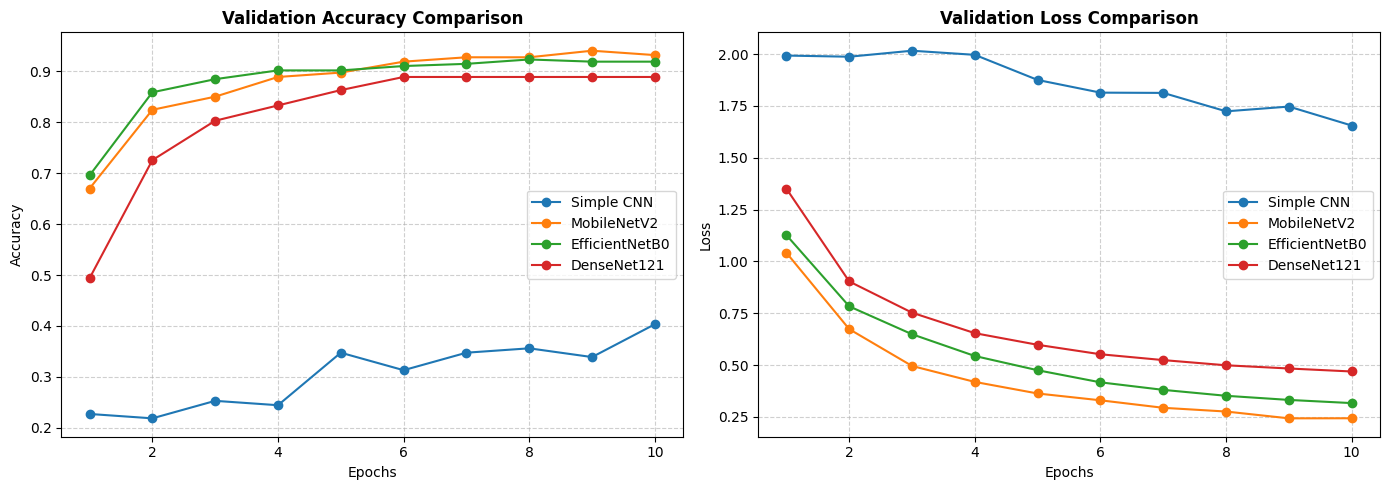

Generating predictions for Simple CNN...
Generating predictions for MobileNetV2...
Generating predictions for EfficientNetB0...
Generating predictions for DenseNet121...

             OVERALL MODEL PERFORMANCE SUMMARY
         Model  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)
   MobileNetV2  0.931330              0.934563           0.931330             0.931225
EfficientNetB0  0.918455              0.925025           0.918455             0.919091
   DenseNet121  0.888412              0.887957           0.888412             0.885453
    Simple CNN  0.403433              0.407095           0.403433             0.368549

 CLASSIFICATION REPORT: MOBILENETV2 (TOP PERFORMER)
                            precision    recall  f1-score   support

            BA- cellulitis       0.86      0.97      0.91        33
               BA-impetigo       0.95      0.90      0.92        20
           FU-athlete-foot       0.91      1.00      0.96        32
            FU-nail-f

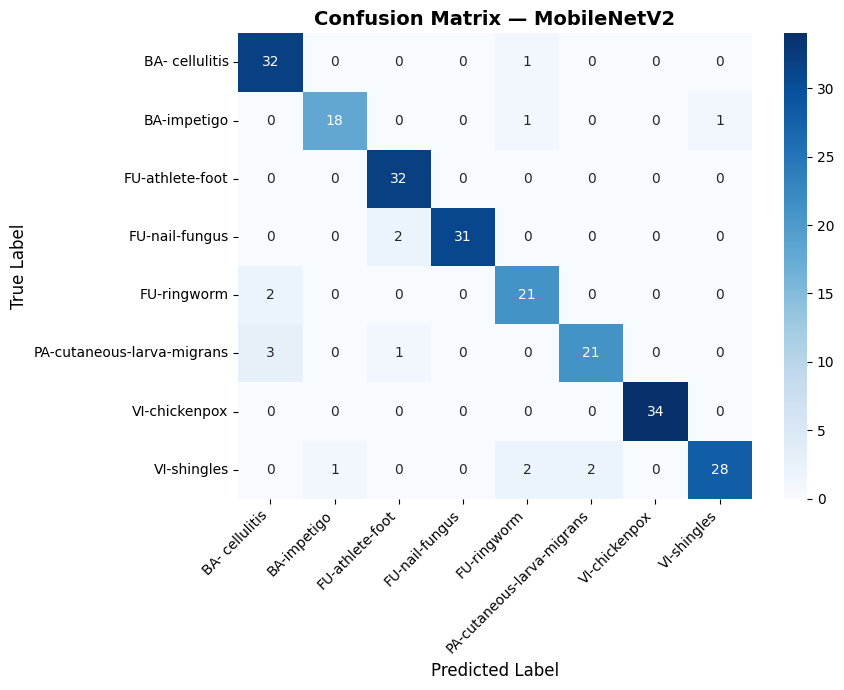

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ----------------------------------------------------
# 0. Global Hyperparameters (Customized for Experiment)
# ----------------------------------------------------
# ----------------------------------------------------
# Optimized Hyperparameters for Stage 1 (Frozen Backbone)
# ----------------------------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32         # Revert to 32 to maintain sufficient gradient steps
LEARNING_RATE = 1e-3    # 1e-3 is essential for training the dense head from scratch
WEIGHT_DECAY = 1e-5     # Mild weight decay
EPOCHS = 10

def get_optimizer():
    return tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

def build_mobilenet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    base_model = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_tensor=x
    )
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)  # Moderate dropout
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="MobileNetV2")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ----------------------------------------------------
# 1. Path Resolution & Dataset Loading
# ----------------------------------------------------
train_dir = os.path.join(path, "skin-disease-datasaet", "train_set")
test_dir = os.path.join(path, "skin-disease-datasaet", "test_set")

if not os.path.exists(train_dir):
    train_dir = os.path.join(path, "train_set")
    test_dir = os.path.join(path, "test_set")

print(f"Train directory: {train_dir}")
print(f"Test directory:  {test_dir}")

# Load Training Set
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

# Load Validation/Test Set
val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nSuccessfully loaded {num_classes} classes:")
for i, name in enumerate(class_names):
    print(f"  [{i}] {name}")

# ----------------------------------------------------
# 2. Optimized Pipeline & Data Augmentation
# ----------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

train_ds_proc = train_ds.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
val_ds_proc = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ----------------------------------------------------
# 3. Model Architectures (with L2 Regularizers)
# ----------------------------------------------------
def build_simple_cnn(num_classes):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, activation='relu', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)),
        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ], name="Simple_CNN")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_mobilenet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax', kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="MobileNetV2")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_efficientnet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax', kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="EfficientNetB0")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_densenet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.densenet.preprocess_input(x)
    base_model = tf.keras.applications.DenseNet121(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax', kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="DenseNet121")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ----------------------------------------------------
# 4. Multi-Model Training with Callbacks
# ----------------------------------------------------
models_to_train = {
    "Simple CNN": build_simple_cnn(num_classes),
    "MobileNetV2": build_mobilenet_model(num_classes),
    "EfficientNetB0": build_efficientnet_model(num_classes),
    "DenseNet121": build_densenet_model(num_classes)
}

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

histories = {}
for name, model in models_to_train.items():
    print(f"\n" + "="*50)
    print(f" TRAINING: {name} (LR: {LEARNING_RATE}, Weight Decay: {WEIGHT_DECAY})")
    print("="*50)
    histories[name] = model.fit(
        train_ds_proc,
        validation_data=val_ds_proc,
        epochs=EPOCHS,
        callbacks=callbacks
    )

# ----------------------------------------------------
# 5. Training History Visualizations
# ----------------------------------------------------
def plot_all_models(history_dict):
    plt.figure(figsize=(14, 5))

    # Validation Accuracy Plot
    plt.subplot(1, 2, 1)
    for name, hist in history_dict.items():
        epochs_range = range(1, len(hist.history['val_accuracy']) + 1)
        plt.plot(epochs_range, hist.history['val_accuracy'], marker='o', label=f'{name}')
    plt.title('Validation Accuracy Comparison', fontsize=12, weight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Validation Loss Plot
    plt.subplot(1, 2, 2)
    for name, hist in history_dict.items():
        epochs_range = range(1, len(hist.history['val_loss']) + 1)
        plt.plot(epochs_range, hist.history['val_loss'], marker='o', label=f'{name}')
    plt.title('Validation Loss Comparison', fontsize=12, weight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_all_models(histories)

# ----------------------------------------------------
# 6. Performance Evaluation & Classification Metrics
# ----------------------------------------------------
y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

metrics_summary = []
predictions_dict = {}

for name, model in models_to_train.items():
    print(f"Generating predictions for {name}...")
    y_prob = model.predict(val_ds_proc, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    predictions_dict[name] = y_pred

    metrics_summary.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Weighted)": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall (Weighted)": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1-Score (Weighted)": f1_score(y_true, y_pred, average='weighted', zero_division=0)
    })

# Summary Table
df_metrics = pd.DataFrame(metrics_summary).sort_values(by="F1-Score (Weighted)", ascending=False).reset_index(drop=True)
print("\n" + "="*65)
print("             OVERALL MODEL PERFORMANCE SUMMARY")
print("="*65)
print(df_metrics.to_string(index=False))

# Best Model Classification Report
best_model_name = df_metrics.iloc[0]["Model"]
best_pred = predictions_dict[best_model_name]

print("\n" + "="*65)
print(f" CLASSIFICATION REPORT: {best_model_name.upper()} (TOP PERFORMER)")
print("="*65)
print(classification_report(y_true, best_pred, target_names=class_names, zero_division=0))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, best_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14, weight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Train directory: /kaggle/input/skin-disease-dataset/skin-disease-datasaet/train_set
Test directory:  /kaggle/input/skin-disease-dataset/skin-disease-datasaet/test_set
Found 924 files belonging to 8 classes.
Found 233 files belonging to 8 classes.

Successfully loaded 8 classes:
  [0] BA- cellulitis
  [1] BA-impetigo
  [2] FU-athlete-foot
  [3] FU-nail-fungus
  [4] FU-ringworm
  [5] PA-cutaneous-larva-migrans
  [6] VI-chickenpox
  [7] VI-shingles


/tmp/ipykernel_3296/2917022359.py:110: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=x)



 TRAINING: Simple CNN (LR: 0.001, Weight Decay: 1e-05)
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.1569 - loss: 3.2483 - val_accuracy: 0.2489 - val_loss: 1.9675 - learning_rate: 0.0010
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.2089 - loss: 1.9889 - val_accuracy: 0.2017 - val_loss: 1.9570 - learning_rate: 0.0010
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.2240 - loss: 1.9393 - val_accuracy: 0.3348 - val_loss: 1.9349 - learning_rate: 0.0010
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.2348 - loss: 2.0007 - val_accuracy: 0.2876 - val_loss: 1.9394 - learning_rate: 0.0010
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.2435 - loss: 1.9589 - val_accuracy: 0.3004 - val_loss: 1.9314 - learning_rate: 0.0010
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.2532 - loss: 1.9432 - val_accuracy: 0.2403 - val_loss: 2.0055 - learning_rate: 0.0010
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 

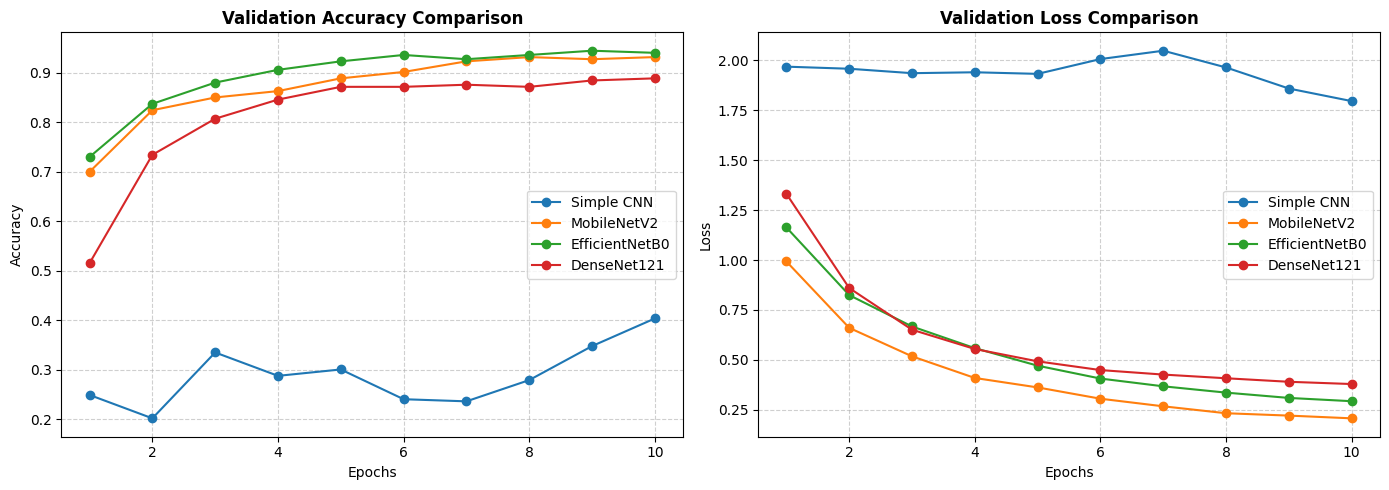

Generating predictions for Simple CNN...
Generating predictions for MobileNetV2...
Generating predictions for EfficientNetB0...
Generating predictions for DenseNet121...

             OVERALL MODEL PERFORMANCE SUMMARY
         Model  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)
EfficientNetB0  0.939914              0.943389           0.939914             0.939785
   MobileNetV2  0.931330              0.932386           0.931330             0.931015
   DenseNet121  0.888412              0.888396           0.888412             0.886420
    Simple CNN  0.403433              0.410986           0.403433             0.357760

 CLASSIFICATION REPORT: EFFICIENTNETB0 (TOP PERFORMER)
                            precision    recall  f1-score   support

            BA- cellulitis       0.94      1.00      0.97        33
               BA-impetigo       1.00      0.90      0.95        20
           FU-athlete-foot       0.94      0.97      0.95        32
            FU-nai

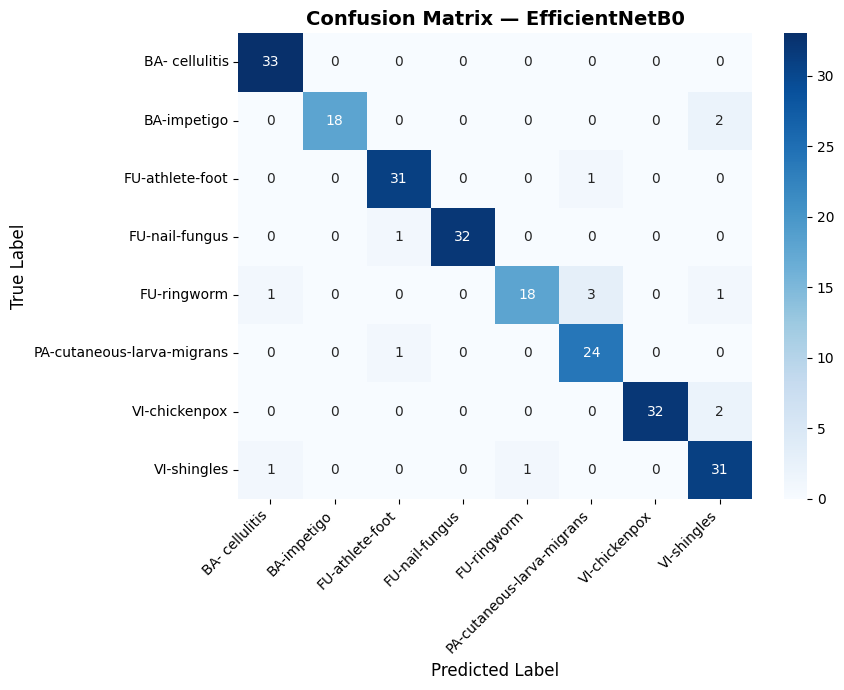

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ----------------------------------------------------
# 0. Global Hyperparameters (Optimized for Stage 1)
# ----------------------------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32         # Restored to 32 for sufficient optimization steps
LEARNING_RATE = 1e-3    # Essential learning rate for training heads from scratch
WEIGHT_DECAY = 1e-5     # Mild weight decay via AdamW
EPOCHS = 10

def get_optimizer():
    """Generates a fresh AdamW optimizer instance for each model."""
    return tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

# ----------------------------------------------------
# 1. Path Resolution & Dataset Loading
# ----------------------------------------------------
train_dir = os.path.join(path, "skin-disease-datasaet", "train_set")
test_dir = os.path.join(path, "skin-disease-datasaet", "test_set")

# Fallback in case directory hierarchy differs
if not os.path.exists(train_dir):
    train_dir = os.path.join(path, "train_set")
    test_dir = os.path.join(path, "test_set")

print(f"Train directory: {train_dir}")
print(f"Test directory:  {test_dir}")

# Load Training Set
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

# Load Validation/Test Set
val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nSuccessfully loaded {num_classes} classes:")
for i, name in enumerate(class_names):
    print(f"  [{i}] {name}")

# ----------------------------------------------------
# 2. Optimized Pipeline & Data Augmentation
# ----------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

train_ds_proc = train_ds.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
val_ds_proc = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ----------------------------------------------------
# 3. Model Architectures
# ----------------------------------------------------
def build_simple_cnn(num_classes):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ], name="Simple_CNN")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_mobilenet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="MobileNetV2")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_efficientnet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="EfficientNetB0")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_densenet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.densenet.preprocess_input(x)
    base_model = tf.keras.applications.DenseNet121(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="DenseNet121")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ----------------------------------------------------
# 4. Multi-Model Training
# ----------------------------------------------------
models_to_train = {
    "Simple CNN": build_simple_cnn(num_classes),
    "MobileNetV2": build_mobilenet_model(num_classes),
    "EfficientNetB0": build_efficientnet_model(num_classes),
    "DenseNet121": build_densenet_model(num_classes)
}

# Callback to smoothly reduce learning rate once the head starts plateauing
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]

histories = {}
for name, model in models_to_train.items():
    print(f"\n" + "="*50)
    print(f" TRAINING: {name} (LR: {LEARNING_RATE}, Weight Decay: {WEIGHT_DECAY})")
    print("="*50)
    histories[name] = model.fit(
        train_ds_proc,
        validation_data=val_ds_proc,
        epochs=EPOCHS,
        callbacks=callbacks
    )

# ----------------------------------------------------
# 5. Training History Visualizations
# ----------------------------------------------------
def plot_all_models(history_dict):
    plt.figure(figsize=(14, 5))

    # Validation Accuracy Plot
    plt.subplot(1, 2, 1)
    for name, hist in history_dict.items():
        epochs_range = range(1, len(hist.history['val_accuracy']) + 1)
        plt.plot(epochs_range, hist.history['val_accuracy'], marker='o', label=f'{name}')
    plt.title('Validation Accuracy Comparison', fontsize=12, weight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Validation Loss Plot
    plt.subplot(1, 2, 2)
    for name, hist in history_dict.items():
        epochs_range = range(1, len(hist.history['val_loss']) + 1)
        plt.plot(epochs_range, hist.history['val_loss'], marker='o', label=f'{name}')
    plt.title('Validation Loss Comparison', fontsize=12, weight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_all_models(histories)

# ----------------------------------------------------
# 6. Performance Evaluation & Classification Metrics
# ----------------------------------------------------
y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

metrics_summary = []
predictions_dict = {}

for name, model in models_to_train.items():
    print(f"Generating predictions for {name}...")
    y_prob = model.predict(val_ds_proc, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    predictions_dict[name] = y_pred

    metrics_summary.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Weighted)": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall (Weighted)": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1-Score (Weighted)": f1_score(y_true, y_pred, average='weighted', zero_division=0)
    })

# Summary Table
df_metrics = pd.DataFrame(metrics_summary).sort_values(by="F1-Score (Weighted)", ascending=False).reset_index(drop=True)
print("\n" + "="*65)
print("             OVERALL MODEL PERFORMANCE SUMMARY")
print("="*65)
print(df_metrics.to_string(index=False))

# Best Model Classification Report
best_model_name = df_metrics.iloc[0]["Model"]
best_pred = predictions_dict[best_model_name]

print("\n" + "="*65)
print(f" CLASSIFICATION REPORT: {best_model_name.upper()} (TOP PERFORMER)")
print("="*65)
print(classification_report(y_true, best_pred, target_names=class_names, zero_division=0))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, best_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14, weight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Train directory: /kaggle/input/skin-disease-dataset/skin-disease-datasaet/train_set
Test directory:  /kaggle/input/skin-disease-dataset/skin-disease-datasaet/test_set
Found 924 files belonging to 8 classes.
Found 233 files belonging to 8 classes.

Successfully loaded 8 classes:
  [0] BA- cellulitis
  [1] BA-impetigo
  [2] FU-athlete-foot
  [3] FU-nail-fungus
  [4] FU-ringworm
  [5] PA-cutaneous-larva-migrans
  [6] VI-chickenpox
  [7] VI-shingles


/tmp/ipykernel_3296/2136322423.py:110: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=x)



 TRAINING: Simple CNN (LR: 0.001, Weight Decay: 1e-05)
Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.1688 - loss: 3.8203 - val_accuracy: 0.2361 - val_loss: 1.9206 - learning_rate: 0.0010
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.2370 - loss: 1.9758 - val_accuracy: 0.2661 - val_loss: 1.8938 - learning_rate: 0.0010
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.2760 - loss: 1.9214 - val_accuracy: 0.3047 - val_loss: 1.8978 - learning_rate: 0.0010
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.2587 - loss: 1.9446 - val_accuracy: 0.2532 - val_loss: 1.9822 - learning_rate: 0.0010
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.2812 - loss: 1.9266
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.2619 - loss: 1.9469 - val_accuracy: 0.2790 - val_loss: 1.9239 - learning_rate: 0.0010
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2

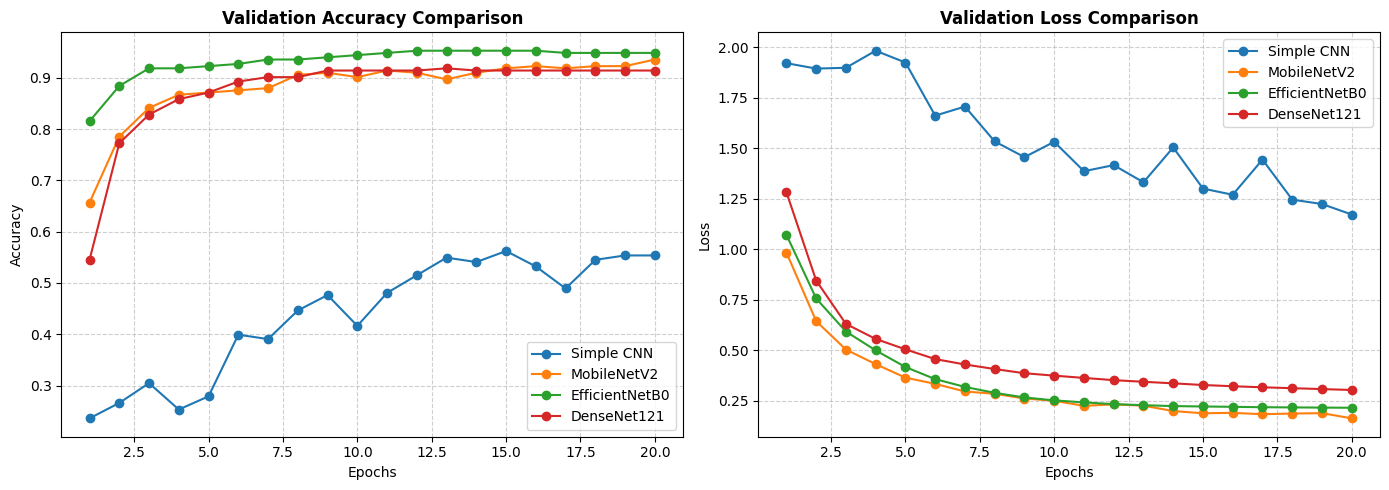

Generating predictions for Simple CNN...
Generating predictions for MobileNetV2...
Generating predictions for EfficientNetB0...
Generating predictions for DenseNet121...

             OVERALL MODEL PERFORMANCE SUMMARY
         Model  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)
EfficientNetB0  0.948498              0.950784           0.948498             0.948726
   MobileNetV2  0.935622              0.937042           0.935622             0.935782
   DenseNet121  0.914163              0.917517           0.914163             0.913777
    Simple CNN  0.553648              0.560408           0.553648             0.549387

 CLASSIFICATION REPORT: EFFICIENTNETB0 (TOP PERFORMER)
                            precision    recall  f1-score   support

            BA- cellulitis       0.94      0.97      0.96        33
               BA-impetigo       1.00      1.00      1.00        20
           FU-athlete-foot       0.97      0.97      0.97        32
            FU-nai

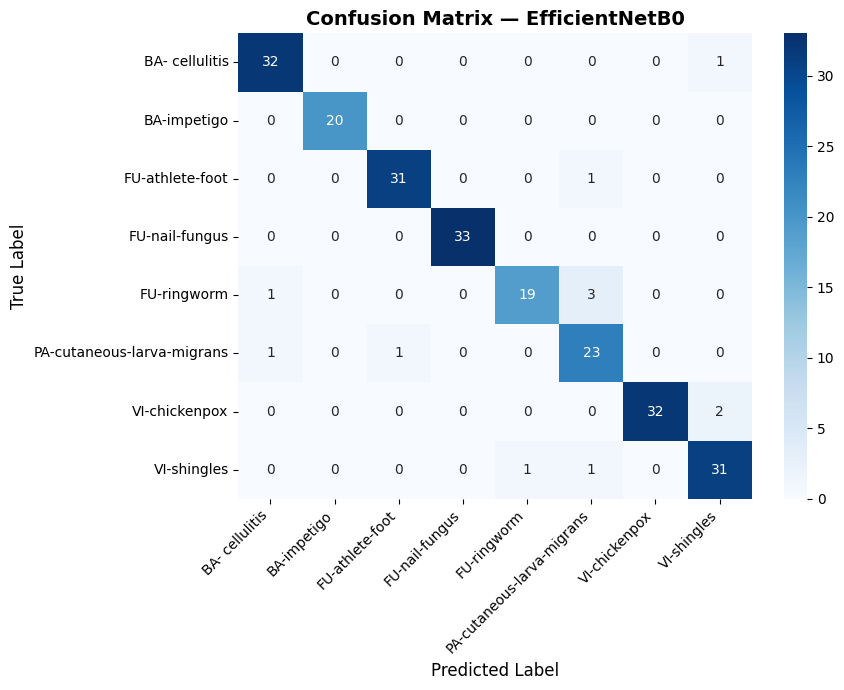

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ----------------------------------------------------
# 0. Global Hyperparameters (Optimized for Stage 1)
# ----------------------------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32         # Restored to 32 for sufficient optimization steps
LEARNING_RATE = 1e-3    # Essential learning rate for training heads from scratch
WEIGHT_DECAY = 1e-5     # Mild weight decay via AdamW
EPOCHS = 20

def get_optimizer():
    """Generates a fresh AdamW optimizer instance for each model."""
    return tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

# ----------------------------------------------------
# 1. Path Resolution & Dataset Loading
# ----------------------------------------------------
train_dir = os.path.join(path, "skin-disease-datasaet", "train_set")
test_dir = os.path.join(path, "skin-disease-datasaet", "test_set")

# Fallback in case directory hierarchy differs
if not os.path.exists(train_dir):
    train_dir = os.path.join(path, "train_set")
    test_dir = os.path.join(path, "test_set")

print(f"Train directory: {train_dir}")
print(f"Test directory:  {test_dir}")

# Load Training Set
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

# Load Validation/Test Set
val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nSuccessfully loaded {num_classes} classes:")
for i, name in enumerate(class_names):
    print(f"  [{i}] {name}")

# ----------------------------------------------------
# 2. Optimized Pipeline & Data Augmentation
# ----------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

train_ds_proc = train_ds.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
val_ds_proc = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ----------------------------------------------------
# 3. Model Architectures
# ----------------------------------------------------
def build_simple_cnn(num_classes):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ], name="Simple_CNN")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_mobilenet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="MobileNetV2")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_efficientnet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="EfficientNetB0")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_densenet_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.densenet.preprocess_input(x)
    base_model = tf.keras.applications.DenseNet121(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="DenseNet121")
    model.compile(optimizer=get_optimizer(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ----------------------------------------------------
# 4. Multi-Model Training
# ----------------------------------------------------
models_to_train = {
    "Simple CNN": build_simple_cnn(num_classes),
    "MobileNetV2": build_mobilenet_model(num_classes),
    "EfficientNetB0": build_efficientnet_model(num_classes),
    "DenseNet121": build_densenet_model(num_classes)
}

# Callback to smoothly reduce learning rate once the head starts plateauing
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]

histories = {}
for name, model in models_to_train.items():
    print(f"\n" + "="*50)
    print(f" TRAINING: {name} (LR: {LEARNING_RATE}, Weight Decay: {WEIGHT_DECAY})")
    print("="*50)
    histories[name] = model.fit(
        train_ds_proc,
        validation_data=val_ds_proc,
        epochs=EPOCHS,
        callbacks=callbacks
    )

# ----------------------------------------------------
# 5. Training History Visualizations
# ----------------------------------------------------
def plot_all_models(history_dict):
    plt.figure(figsize=(14, 5))

    # Validation Accuracy Plot
    plt.subplot(1, 2, 1)
    for name, hist in history_dict.items():
        epochs_range = range(1, len(hist.history['val_accuracy']) + 1)
        plt.plot(epochs_range, hist.history['val_accuracy'], marker='o', label=f'{name}')
    plt.title('Validation Accuracy Comparison', fontsize=12, weight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Validation Loss Plot
    plt.subplot(1, 2, 2)
    for name, hist in history_dict.items():
        epochs_range = range(1, len(hist.history['val_loss']) + 1)
        plt.plot(epochs_range, hist.history['val_loss'], marker='o', label=f'{name}')
    plt.title('Validation Loss Comparison', fontsize=12, weight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_all_models(histories)

# ----------------------------------------------------
# 6. Performance Evaluation & Classification Metrics
# ----------------------------------------------------
y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

metrics_summary = []
predictions_dict = {}

for name, model in models_to_train.items():
    print(f"Generating predictions for {name}...")
    y_prob = model.predict(val_ds_proc, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    predictions_dict[name] = y_pred

    metrics_summary.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Weighted)": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall (Weighted)": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1-Score (Weighted)": f1_score(y_true, y_pred, average='weighted', zero_division=0)
    })

# Summary Table
df_metrics = pd.DataFrame(metrics_summary).sort_values(by="F1-Score (Weighted)", ascending=False).reset_index(drop=True)
print("\n" + "="*65)
print("             OVERALL MODEL PERFORMANCE SUMMARY")
print("="*65)
print(df_metrics.to_string(index=False))

# Best Model Classification Report
best_model_name = df_metrics.iloc[0]["Model"]
best_pred = predictions_dict[best_model_name]

print("\n" + "="*65)
print(f" CLASSIFICATION REPORT: {best_model_name.upper()} (TOP PERFORMER)")
print("="*65)
print(classification_report(y_true, best_pred, target_names=class_names, zero_division=0))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, best_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14, weight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()